<a href="https://colab.research.google.com/github/Sharvil2704/qrcode/blob/main/brain_tumour_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumour MRI — WGAN-GP Synthetic Augmentation

**Goal.** Use a GAN to generate synthetic brain-tumour MRI images for a *minority*
class, then test whether adding them to an imbalanced training set improves a
downstream tumour classifier.

**Pipeline.** (1) data + EDA → (2) baseline classifier on imbalanced data →
(3) **WGAN-GP** generator for the minority class → (4) augment with synthetic
images → (5) re-train the *same* classifier and compare.

**A GAN in one paragraph.** Two networks play a game. The **generator** maps a
random latent vector `z ~ N(0, I)` to a fake image; it never sees real data
directly. The **critic** scores how real an image looks. They train
adversarially — the critic learns to tell real from fake, the generator learns to
fool it — until the generator's samples are indistinguishable from real data.

> **Portability.** Runs unmodified on local Apple Silicon (MPS), Google Colab
> (CUDA), or CPU. Device order is `cuda → mps → cpu`; a single config cell holds
> all paths/hyperparameters; `PYTORCH_ENABLE_MPS_FALLBACK=1` lets unsupported
> Metal ops fall back to CPU instead of crashing.

> **Not for clinical use.** Synthetic medical images here are a coursework
> demonstration only — see the Discussion at the end.

## 1 · Setup & configuration

Installs, imports, environment flags, device detection, reproducibility seed, and
a single `CFG` object that every later cell reads from.

In [1]:
# Install deps not always present (quiet). pytorch-fid -> FID metric; kagglehub
# -> optional dataset download on Colab. Safe to re-run.
import importlib, subprocess, sys
for pkg, mod in [("pytorch-fid", "pytorch_fid"), ("scikit-image", "skimage"), ("kagglehub", "kagglehub")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

In [2]:
import os
# MUST be set before any MPS tensor work so unsupported ops fall back to CPU.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import copy, math, random
from collections import Counter, defaultdict
from itertools import cycle

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.exposure import equalize_adapthist  # CLAHE contrast enhancement

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.utils as vutils
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("torch", torch.__version__)

torch 2.11.0+cu128


**Device & Colab detection.** We prefer an NVIDIA GPU (Colab), then Apple's Metal
GPU (local), then CPU. Colab is detected only to branch the dataset path.

In [3]:
def on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

ON_COLAB = on_colab()

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print(f"on_colab={ON_COLAB}  device={device}")

on_colab=True  device=cuda


**Config.** One object holds every path and hyperparameter. Defaults are the ones
that produced the reported results (128 px, the tuned WGAN-GP recipe).

> To run faster on a fresh machine, lower `GAN_EPOCHS` and `CLF_EPOCHS`. The
> provided generator checkpoint (`gen_best_fid.pt`) reproduces the reported
> samples without retraining (see the GAN section).

In [4]:
class CFG:
    # paths -- Colab downloads via kagglehub; locally point at the extracted folder
    if ON_COLAB:
        DATA_ROOT = "/content/brain-tumor-mri-dataset"
    else:
        DATA_ROOT = "brain-tumor-mri-dataset"   # contains Training/ and Testing/
    TRAIN_DIR, TEST_DIR = "Training", "Testing"
    OUT_DIR = "outputs"
    CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

    # data / encoding
    IMG_SIZE = 128            # models adapt to any power-of-2 size (64/128/256)
    CHANNELS = 1              # MRI -> grayscale
    USE_CLAHE = True          # contrast-enhance the brain (features were washed out)
    VAL_FRAC = 0.15           # stratified val carved from Training/

    # controlled imbalance: dataset is balanced on disk, so we down-sample one
    # class in TRAIN only to create a realistic minority for the study.
    MINORITY_CLASS = "glioma"
    MINORITY_KEEP_FRAC = 0.15

    # classifier
    CLF_BATCH, CLF_EPOCHS, CLF_LR = 64, 15, 1e-3

    # WGAN-GP (tuned recipe)
    Z_DIM = 100
    GAN_BATCH = 64
    GAN_EPOCHS = 250          # ~3.7 h on MPS; faster on Colab GPU. Lower for a quick run.
    GAN_HFLIP = True          # flip reals: ~2x data + more view diversity
    GEN_ITERS_PER_EPOCH = 25  # generator iters per epoch (tiny dataset workaround)
    G_LR, D_LR = 2e-4, 1e-4   # TTUR: generator LR > critic LR
    GAN_BETAS = (0.0, 0.9)
    N_CRITIC = 3              # critic updates per generator update
    GP_LAMBDA = 10.0          # gradient-penalty weight
    GAN_FEAT = 64
    EMA_DECAY = 0.995         # generator weight EMA (sample/FID/checkpoint from it)
    EVAL_EVERY = 10

    # augmentation
    AUG_TARGET = 1190         # bring minority up to majority size with synthetics
    GEN_CKPT = "gen_best_fid.pt"

    SEED = 42
    NUM_WORKERS = 0           # 0 safest on MPS; raise on CUDA

os.makedirs(CFG.OUT_DIR, exist_ok=True)
set_seed(CFG.SEED)

**Dataset access.** Locally the data is already extracted. On Colab we try
`kagglehub`; if credentials/data are missing we print manual instructions instead
of crashing.

In [5]:
def ensure_dataset():
    if os.path.isdir(os.path.join(CFG.DATA_ROOT, CFG.TRAIN_DIR)):
        print(f"dataset found at {os.path.abspath(CFG.DATA_ROOT)}")
        return
    try:
        import kagglehub
        path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
        CFG.DATA_ROOT = path
        print("downloaded via kagglehub ->", path)
        return
    except Exception as e:
        print("kagglehub download failed:", e)
    print(
        "\nDataset not found. Manual steps:\n"
        " 1. Get 'Brain Tumor MRI Dataset' (masoudnickparvar) from Kaggle.\n"
        " 2. Extract so that <DATA_ROOT>/Training and <DATA_ROOT>/Testing exist.\n"
        " 3. Set CFG.DATA_ROOT to that folder and re-run."
    )

ensure_dataset()

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
downloaded via kagglehub -> /kaggle/input/brain-tumor-mri-dataset


## 2 · Data, EDA & the train/val/test split

**Why imbalance matters (theory).** An imbalanced classifier can raise overall
accuracy by mostly ignoring the rare class — so accuracy *alone hides the
failure*. We therefore report **per-class precision/recall + macro-F1** and a
confusion matrix, and we deliberately create a minority class to study.

**Split protocol (for honest evaluation).**
- **Test** = the original `Testing/` folder, untouched until the final numbers.
- **Validation** = 15 % of `Training/`, stratified — used for model selection.
- **Train** = the rest of `Training/`, with `glioma` down-sampled to 15 % to
  induce a ~6.7× imbalance. Val/test keep the true balanced distribution.

In [6]:
def scan_split(split_dir):
    root = os.path.join(CFG.DATA_ROOT, split_dir)
    items = []
    for ci, cls in enumerate(CFG.CLASSES):
        cdir = os.path.join(root, cls)
        if os.path.isdir(cdir):
            for fn in os.listdir(cdir):
                if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                    items.append((os.path.join(cdir, fn), ci))
    return items

def counts(items):
    c = Counter(l for _, l in items)
    return {CFG.CLASSES[i]: c.get(i, 0) for i in range(len(CFG.CLASSES))}

def build_splits(verbose=True):
    set_seed(CFG.SEED)
    train_pool = scan_split(CFG.TRAIN_DIR)
    test_items = scan_split(CFG.TEST_DIR)

    by_cls = defaultdict(list)
    for p, l in train_pool:
        by_cls[l].append(p)

    train_items, val_items = [], []
    for lbl, paths in by_cls.items():
        paths = paths[:]; random.shuffle(paths)
        n_val = int(round(len(paths) * CFG.VAL_FRAC))
        val_paths, tr_paths = paths[:n_val], paths[n_val:]
        if CFG.CLASSES[lbl] == CFG.MINORITY_CLASS:       # induce imbalance
            keep = max(1, int(round(len(tr_paths) * CFG.MINORITY_KEEP_FRAC)))
            tr_paths = tr_paths[:keep]
        train_items += [(p, lbl) for p in tr_paths]
        val_items += [(p, lbl) for p in val_paths]
    random.shuffle(train_items)

    if verbose:
        tr, va, te = counts(train_items), counts(val_items), counts(test_items)
        print(f"{'class':<12}{'train':>8}{'val':>8}{'test':>8}")
        for c in CFG.CLASSES:
            tag = "  <-- minority" if c == CFG.MINORITY_CLASS else ""
            print(f"{c:<12}{tr[c]:>8}{va[c]:>8}{te[c]:>8}{tag}")
        print(f"imbalance ratio (train max/min): "
              f"{max(tr.values())/max(1,min(tr.values())):.1f}x")
    return train_items, val_items, test_items

train_items, val_items, test_items = build_splits()

class          train     val    test
glioma           178     210     400  <-- minority
meningioma      1190     210     400
notumor         1190     210     400
pituitary       1190     210     400
imbalance ratio (train max/min): 6.7x


**Input encoding (CLAHE).** Raw scans push the brain tissue into the low-intensity
band (lots of black background + a few bright skull pixels), so tumour/tissue
features look washed out. **CLAHE** (Contrast-Limited Adaptive Histogram
Equalisation) redistributes intensities within local tiles, making internal
structure visible — easier for both the GAN and us. Images are normalised to
`[-1, 1]` to match the generator's `tanh` output.

In [7]:
def preprocess_image(path):
    '''grayscale -> resize -> (CLAHE) -> tensor in [-1,1].'''
    img = Image.open(path).convert("L").resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    if CFG.USE_CLAHE:
        arr = equalize_adapthist(arr, clip_limit=0.02).astype(np.float32)
    return torch.from_numpy(arr).unsqueeze(0) * 2.0 - 1.0   # (1,H,W) in [-1,1]

class MRIDataset(Dataset):
    '''Caches the deterministic CLAHE encoding once; optional random hflip.'''
    def __init__(self, items, train=False, augment=None):
        self.augment = train if augment is None else augment
        self.cache = [preprocess_image(p) for p, _ in items]
        self.labels = [l for _, l in items]
    def __len__(self):
        return len(self.cache)
    def deterministic_tensor(self, i):
        return self.cache[i]
    def __getitem__(self, i):
        x = self.cache[i]
        if self.augment and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
        return x, self.labels[i]

**EDA figures.** Class distribution (the induced imbalance), sample MRIs per class, and the raw-vs-CLAHE encoding comparison.

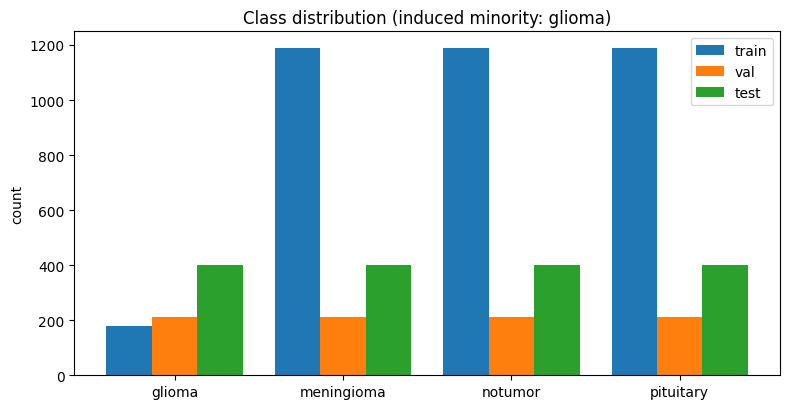

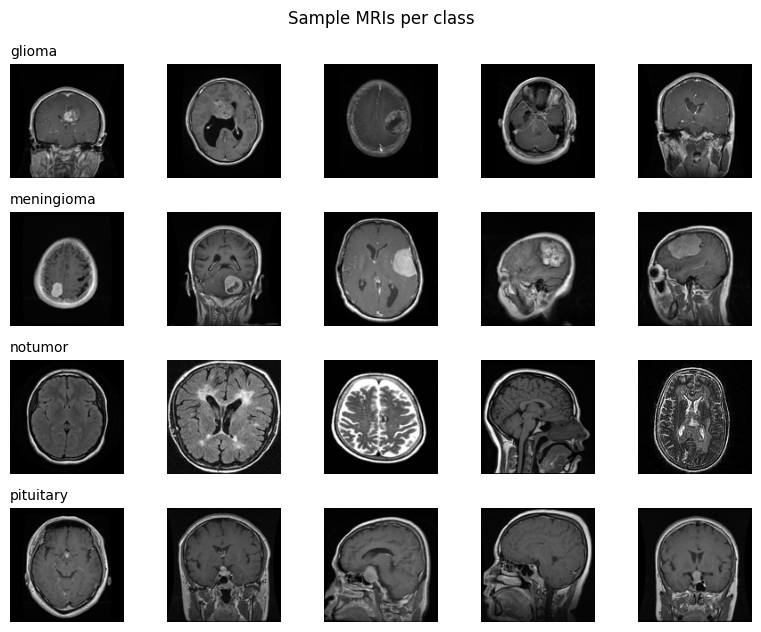

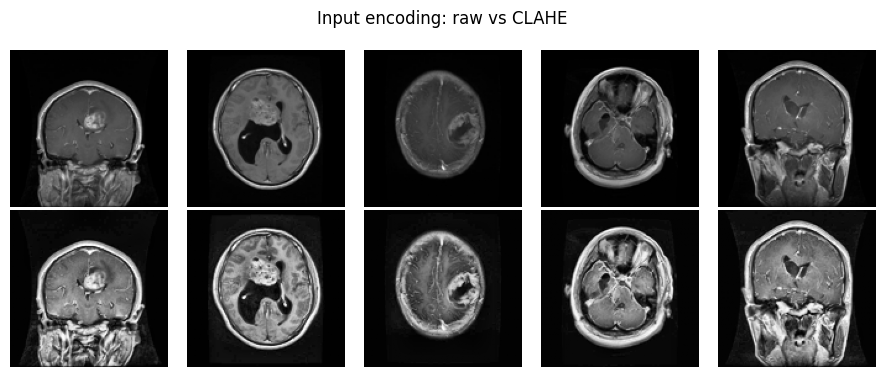

In [8]:
def show_class_distribution(tr, va, te):
    t, v, e = counts(tr), counts(va), counts(te)
    x = np.arange(len(CFG.CLASSES)); w = 0.27
    plt.figure(figsize=(8, 4.2))
    plt.bar(x - w, [t[c] for c in CFG.CLASSES], w, label="train")
    plt.bar(x, [v[c] for c in CFG.CLASSES], w, label="val")
    plt.bar(x + w, [e[c] for c in CFG.CLASSES], w, label="test")
    plt.xticks(x, CFG.CLASSES); plt.ylabel("count")
    plt.title(f"Class distribution (induced minority: {CFG.MINORITY_CLASS})")
    plt.legend(); plt.tight_layout(); plt.show()

def show_sample_grid(items, n=5):
    by = defaultdict(list)
    for p, l in items:
        by[l].append(p)
    fig, ax = plt.subplots(len(CFG.CLASSES), n, figsize=(n*1.6, len(CFG.CLASSES)*1.6))
    for r, c in enumerate(CFG.CLASSES):
        for j in range(n):
            ax[r, j].axis("off")
            if j < len(by[r]):
                im = Image.open(by[r][j]).convert("L").resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
                ax[r, j].imshow(im, cmap="gray")
            if j == 0:
                ax[r, j].set_title(c, loc="left", fontsize=10)
    fig.suptitle("Sample MRIs per class"); fig.tight_layout(); plt.show()

def show_clahe_comparison(items, n=5):
    idx = CFG.CLASSES.index(CFG.MINORITY_CLASS)
    paths = [p for p, l in items if l == idx][:n]
    fig, ax = plt.subplots(2, n, figsize=(n*1.8, 3.8))
    for c, p in enumerate(paths):
        raw = Image.open(p).convert("L").resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
        proc = (preprocess_image(p)[0].numpy() + 1) / 2
        ax[0, c].imshow(raw, cmap="gray"); ax[0, c].axis("off")
        ax[1, c].imshow(proc, cmap="gray"); ax[1, c].axis("off")
    ax[0, 0].set_ylabel("raw", rotation=0, labelpad=20)
    ax[1, 0].set_ylabel("CLAHE", rotation=0, labelpad=24)
    fig.suptitle("Input encoding: raw vs CLAHE"); fig.tight_layout(); plt.show()

show_class_distribution(train_items, val_items, test_items)
show_sample_grid(train_items)
show_clahe_comparison(train_items)

## 3 · Baseline classifier (the "before")

A small CNN trained on the imbalanced data. **Protocol:** validate every epoch,
keep the **best-validation-macro-F1** checkpoint, and touch the **test set once**
at the end.

- **Why macro-F1 for selection?** It weights the rare class equally, so the model
  can't "win" by neglecting glioma.
- **Why a separate val set?** Choosing the checkpoint on test would leak test
  information and inflate the final number. Keeping the best-val checkpoint is
  equivalent to early stopping with infinite patience.

The function `run_experiment` is reused unchanged on the augmented data later, so
the before/after comparison is apples-to-apples.

In [9]:
class SmallCNN(nn.Module):
    def __init__(self, in_ch=CFG.CHANNELS, n_classes=len(CFG.CLASSES)):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(True),
                nn.Conv2d(cout, cout, 3, stride=2, padding=1), nn.BatchNorm2d(cout), nn.ReLU(True))
        self.features = nn.Sequential(
            block(in_ch, 32), block(32, 64), block(64, 128), nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.head(self.features(x))

@torch.no_grad()
def predict(model, loader):
    model.eval(); ps, ys = [], []
    for xb, yb in loader:
        ps.append(model(xb.to(device)).argmax(1).cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ps), np.concatenate(ys)

def run_experiment(train_items, val_items, test_items, *, tag, epochs=None, train_ds=None):
    set_seed(CFG.SEED)
    epochs = epochs or CFG.CLF_EPOCHS
    if train_ds is None:
        train_ds = MRIDataset(train_items, train=True)
    val_ds, test_ds = MRIDataset(val_items), MRIDataset(test_items)
    pin = device.type == "cuda"
    tl = DataLoader(train_ds, CFG.CLF_BATCH, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=pin)
    vl = DataLoader(val_ds, CFG.CLF_BATCH, num_workers=CFG.NUM_WORKERS, pin_memory=pin)
    el = DataLoader(test_ds, CFG.CLF_BATCH, num_workers=CFG.NUM_WORKERS, pin_memory=pin)

    model = SmallCNN().to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=CFG.CLF_LR)
    best_f1, best_state, best_ep = -1, None, -1
    hist = {"loss": [], "val_f1": []}
    print(f"\n=== train [{tag}] : {len(train_ds)} imgs, {epochs} epochs ===")
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            run += loss.item() * xb.size(0)
        vp, vy = predict(model, vl); vf1 = f1_score(vy, vp, average="macro")
        hist["loss"].append(run/len(train_ds)); hist["val_f1"].append(vf1)
        flag = ""
        if vf1 > best_f1:
            best_f1, best_ep, best_state = vf1, ep, copy.deepcopy(model.state_dict()); flag = "  * best"
        print(f"epoch {ep:2d}/{epochs}  loss={hist['loss'][-1]:.4f}  val_macroF1={vf1:.4f}{flag}")
    print(f"best epoch={best_ep} (val macroF1={best_f1:.4f})")

    model.load_state_dict(best_state)
    tp, ty = predict(model, el)
    rep = classification_report(ty, tp, target_names=CFG.CLASSES, digits=4, zero_division=0)
    rep_d = classification_report(ty, tp, target_names=CFG.CLASSES, output_dict=True, zero_division=0)
    macro = f1_score(ty, tp, average="macro"); cm = confusion_matrix(ty, tp)
    print(f"\n--- TEST [{tag}] (best-val checkpoint) ---\n{rep}\ntest macro-F1={macro:.4f}")

    fig, a1 = plt.subplots(figsize=(7, 3.8)); xs = range(1, epochs+1)
    a1.plot(xs, hist["loss"], "b-o", ms=3, label="train loss"); a1.set_xlabel("epoch")
    a1.set_ylabel("train loss", color="b"); a2 = a1.twinx()
    a2.plot(xs, hist["val_f1"], "g-s", ms=3); a2.set_ylabel("val macro-F1", color="g")
    a2.axvline(best_ep, color="grey", ls="--", lw=1); plt.title(f"training [{tag}]")
    plt.tight_layout(); plt.show()
    return {"tag": tag, "report": rep_d, "test_macro_f1": macro, "confusion": cm}

def show_confusion(cm, tag):
    plt.figure(figsize=(5, 4.3)); plt.imshow(cm, cmap="Blues")
    plt.xticks(range(len(CFG.CLASSES)), CFG.CLASSES, rotation=45, ha="right")
    plt.yticks(range(len(CFG.CLASSES)), CFG.CLASSES)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.xlabel("predicted"); plt.ylabel("true"); plt.title(f"confusion [{tag}]")
    plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()


=== train [baseline] : 3748 imgs, 15 epochs ===
epoch  1/15  loss=0.7174  val_macroF1=0.2069  * best
epoch  2/15  loss=0.5344  val_macroF1=0.4213  * best
epoch  3/15  loss=0.4276  val_macroF1=0.6610  * best
epoch  4/15  loss=0.4002  val_macroF1=0.8054  * best
epoch  5/15  loss=0.3665  val_macroF1=0.7028
epoch  6/15  loss=0.3377  val_macroF1=0.7384
epoch  7/15  loss=0.2947  val_macroF1=0.5572
epoch  8/15  loss=0.2788  val_macroF1=0.5739
epoch  9/15  loss=0.2522  val_macroF1=0.6813
epoch 10/15  loss=0.2282  val_macroF1=0.6560
epoch 11/15  loss=0.2201  val_macroF1=0.6918
epoch 12/15  loss=0.1810  val_macroF1=0.8012
epoch 13/15  loss=0.1912  val_macroF1=0.8061  * best
epoch 14/15  loss=0.1553  val_macroF1=0.7326
epoch 15/15  loss=0.1272  val_macroF1=0.8650  * best
best epoch=15 (val macroF1=0.8650)

--- TEST [baseline] (best-val checkpoint) ---
              precision    recall  f1-score   support

      glioma     1.0000    0.4075    0.5790       400
  meningioma     0.7066    0.7525    

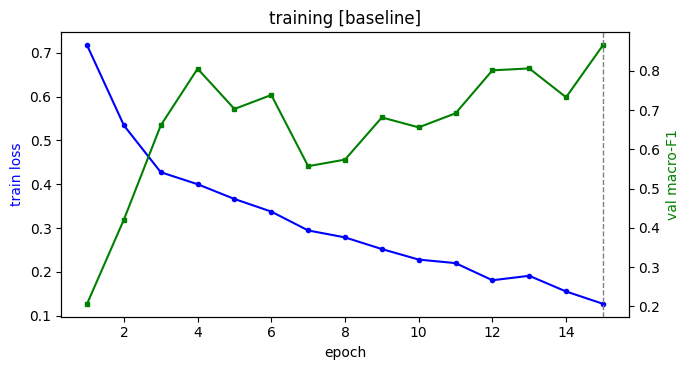

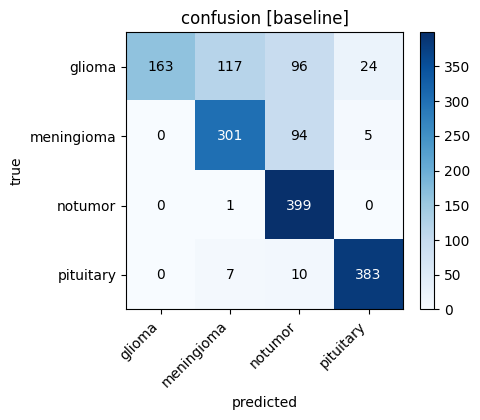

In [20]:
res_baseline = run_experiment(train_items, val_items, test_items, tag="baseline")
show_confusion(res_baseline["confusion"], "baseline")

## 4 · WGAN-GP generator for the minority class

**Why not a vanilla GAN?** The original GAN objective

$$\min_G \max_D \; \mathbb{E}_x[\log D(x)] + \mathbb{E}_z[\log(1 - D(G(z)))]$$

minimises a Jensen–Shannon divergence. When real and fake distributions barely
overlap, that divergence saturates → the generator's gradient **vanishes** and it
often collapses to a few samples (**mode collapse**).

**Wasserstein GAN** instead estimates the **Earth-Mover (Wasserstein-1) distance**,
which varies smoothly even with non-overlapping supports, so the generator always
gets a usable gradient. The **critic** estimates

$$W \approx \max_D \; \mathbb{E}_x[D(x)] - \mathbb{E}_z[D(G(z))], \quad D \text{ is 1-Lipschitz}$$

so it outputs a real-valued score with **no sigmoid** (a distance, not a
probability). The 1-Lipschitz constraint is enforced softly by a **gradient
penalty**:

$$\text{GP} = \mathbb{E}_{\hat x}\big[(\lVert \nabla_{\hat x} D(\hat x)\rVert_2 - 1)^2\big],
\qquad \mathcal{L}_D = \mathbb{E}[D(\text{fake})] - \mathbb{E}[D(\text{real})] + \lambda\,\text{GP}$$

with $\hat x$ sampled on lines between real and fake points and $\lambda=10$. We do
`n_critic` critic updates per generator update and use `Adam(betas=(0.0, 0.9))`.

**DCGAN-style architecture.** Generator = transposed convolutions upsampling
`1→4→…→IMG_SIZE` (BatchNorm + ReLU, final `tanh`). Critic = strided convolutions
down to a single score (LeakyReLU; **InstanceNorm not BatchNorm**, because the
per-sample gradient penalty is broken by BatchNorm's cross-sample coupling).

In [10]:
def n_blocks(img_size):
    n = int(round(math.log2(img_size))) - 2
    assert 2**(n+2) == img_size, "IMG_SIZE must be a power of 2"
    return n

def init_weights(m):
    c = m.__class__.__name__
    if "Conv" in c:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "Norm" in c and getattr(m, "weight", None) is not None:
        nn.init.normal_(m.weight.data, 1.0, 0.02); nn.init.constant_(m.bias.data, 0.0)

class Generator(nn.Module):
    def __init__(self, z_dim=CFG.Z_DIM, ngf=CFG.GAN_FEAT, out_ch=CFG.CHANNELS, img=CFG.IMG_SIZE):
        super().__init__()
        n = n_blocks(img); mults = [2**i for i in range(n-1, -1, -1)]
        layers = [nn.ConvTranspose2d(z_dim, ngf*mults[0], 4, 1, 0, bias=False),
                  nn.BatchNorm2d(ngf*mults[0]), nn.ReLU(True)]
        for i in range(n-1):
            layers += [nn.ConvTranspose2d(ngf*mults[i], ngf*mults[i+1], 4, 2, 1, bias=False),
                       nn.BatchNorm2d(ngf*mults[i+1]), nn.ReLU(True)]
        layers += [nn.ConvTranspose2d(ngf*mults[-1], out_ch, 4, 2, 1), nn.Tanh()]
        self.net = nn.Sequential(*layers); self.apply(init_weights)
    def forward(self, z):
        return self.net(z.view(z.size(0), -1, 1, 1))

class Critic(nn.Module):
    def __init__(self, in_ch=CFG.CHANNELS, ndf=CFG.GAN_FEAT, img=CFG.IMG_SIZE):
        super().__init__()
        n = n_blocks(img); mults = [2**i for i in range(n)]
        layers = [nn.Conv2d(in_ch, ndf*mults[0], 4, 2, 1), nn.LeakyReLU(0.2, True)]
        for i in range(n-1):
            layers += [nn.Conv2d(ndf*mults[i], ndf*mults[i+1], 4, 2, 1),
                       nn.InstanceNorm2d(ndf*mults[i+1], affine=True), nn.LeakyReLU(0.2, True)]
        layers += [nn.Conv2d(ndf*mults[-1], 1, 4, 1, 0)]
        self.net = nn.Sequential(*layers); self.apply(init_weights)
    def forward(self, x):
        return self.net(x).view(-1)

g_, d_ = Generator().to(device), Critic().to(device)
print("G params", sum(p.numel() for p in g_.parameters()),
      "| D params", sum(p.numel() for p in d_.parameters()))
del g_, d_

G params 12784513 | D params 11164353


**FID (Fréchet Inception Distance).** Accuracy can't tell if images *look* real — a
collapsed GAN could output one perfect image and a classifier would be happy. FID
passes real and fake images through a pretrained InceptionV3, models each set's
features as a Gaussian, and computes

$$\text{FID} = \lVert \mu_r - \mu_f \rVert^2 + \mathrm{Tr}\!\big(\Sigma_r + \Sigma_f - 2(\Sigma_r\Sigma_f)^{1/2}\big).$$

Low FID = the fake feature distribution matches the real one. It rewards **both
fidelity and diversity**, so it catches mode collapse. We use it as the GAN's
"validation metric": every few epochs we compute FID and keep the **best-FID**
generator. (With only ~178 real images FID is biased upward — we read the *trend*,
not the absolute value.)

In [11]:
from pytorch_fid.inception import InceptionV3
from pytorch_fid.fid_score import calculate_frechet_distance

def to01(x):
    return (x.clamp(-1, 1) + 1) / 2

class FIDScorer:
    def __init__(self):
        idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
        self.model = InceptionV3([idx]).to(device).eval()
        self.mu_r = self.sig_r = None
    @torch.no_grad()
    def acts(self, imgs01, batch=50):
        if imgs01.size(1) == 1:
            imgs01 = imgs01.repeat(1, 3, 1, 1)
        out = []
        for i in range(0, imgs01.size(0), batch):
            a = self.model(imgs01[i:i+batch].to(device))[0]
            out.append(a.squeeze(-1).squeeze(-1).cpu().numpy())
        return np.concatenate(out)
    def set_real(self, real01):
        a = self.acts(real01); self.mu_r, self.sig_r = a.mean(0), np.cov(a, rowvar=False); return self
    @torch.no_grad()
    def score(self, fake01):
        a = self.acts(fake01)
        return float(calculate_frechet_distance(self.mu_r, self.sig_r, a.mean(0), np.cov(a, rowvar=False)))

**Training the WGAN-GP (tuned recipe).** Key choices, with the reasons we found
matter on this tiny (≈178-image) set:

- **Cycling iterator + fixed `GEN_ITERS_PER_EPOCH`** — with so few batches per
  epoch, a literal "gen step every n_critic batches" loop never fires; we decouple it.
- **TTUR** (`G_LR=2e-4 > D_LR=1e-4`) and **`n_critic=3`** — the critic otherwise
  overpowers the generator and FID plateaus.
- **Generator EMA** — sample/FID/checkpoint from a slow weight-average of the
  generator, which is smoother and sharper than the raw training weights.

Health signals: critic/generator loss curves, the Wasserstein estimate
`E[D(real)]−E[D(fake)]`, FID trend, and sample grids over time. Mode collapse
would show near-identical samples with a stalled/rising FID.

In [12]:
def gradient_penalty(critic, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device=real.device)
    interp = (eps*real + (1-eps)*fake).requires_grad_(True)
    scores = critic(interp)
    grads = torch.autograd.grad(scores, interp, torch.ones_like(scores),
                                create_graph=True, retain_graph=True)[0].view(b, -1)
    return ((grads.norm(2, dim=1) - 1)**2).mean()

def load_minority_reals():
    tr, _, _ = build_splits(verbose=False)
    idx = CFG.CLASSES.index(CFG.MINORITY_CLASS)
    items = [(p, l) for p, l in tr if l == idx]
    ds = MRIDataset(items, augment=CFG.GAN_HFLIP)
    reals = torch.stack([ds.deterministic_tensor(i) for i in range(len(ds))])
    return ds, reals

def train_gan():
    set_seed(CFG.SEED)
    ds, reals = load_minority_reals()
    print(f"WGAN-GP on {len(ds)} real '{CFG.MINORITY_CLASS}' images, device={device}")
    loader = DataLoader(ds, CFG.GAN_BATCH, shuffle=True, drop_last=True, num_workers=CFG.NUM_WORKERS)
    data_iter = cycle(loader)

    G, D = Generator().to(device), Critic().to(device)
    optG = torch.optim.Adam(G.parameters(), lr=CFG.G_LR, betas=CFG.GAN_BETAS)
    optD = torch.optim.Adam(D.parameters(), lr=CFG.D_LR, betas=CFG.GAN_BETAS)
    G_ema = copy.deepcopy(G).eval()
    for p in G_ema.parameters():
        p.requires_grad_(False)
    @torch.no_grad()
    def update_ema(decay=CFG.EMA_DECAY):
        for pe, pr in zip(G_ema.parameters(), G.parameters()):
            pe.mul_(decay).add_(pr.detach(), alpha=1-decay)
        for be, br in zip(G_ema.buffers(), G.buffers()):
            be.copy_(br)

    scorer = FIDScorer().set_real(to01(reals))
    fixed_z = torch.randn(64, CFG.Z_DIM, device=device)
    hist = {"c": [], "g": [], "w": [], "fe": [], "fid": [], "fid_raw": []}
    best_fid = float("inf"); ckpt = os.path.join(CFG.OUT_DIR, CFG.GEN_CKPT)
    grid_dir = os.path.join(CFG.OUT_DIR, "gan_samples"); os.makedirs(grid_dir, exist_ok=True)

    for ep in range(1, CFG.GAN_EPOCHS + 1):
        G.train(); D.train(); ec = eg = ew = nc = ng = 0
        for _ in range(CFG.GEN_ITERS_PER_EPOCH):
            for _ in range(CFG.N_CRITIC):
                real, _l = next(data_iter); real = real.to(device); b = real.size(0)
                fake = G(torch.randn(b, CFG.Z_DIM, device=device)).detach()
                dr, df = D(real).mean(), D(fake).mean()
                lossD = df - dr + CFG.GP_LAMBDA * gradient_penalty(D, real, fake)
                optD.zero_grad(); lossD.backward(); optD.step()
                ec += lossD.item(); ew += (dr - df).item(); nc += 1
            gen = G(torch.randn(CFG.GAN_BATCH, CFG.Z_DIM, device=device))
            lossG = -D(gen).mean()
            optG.zero_grad(); lossG.backward(); optG.step(); update_ema()
            eg += lossG.item(); ng += 1
        hist["c"].append(ec/nc); hist["g"].append(eg/ng); hist["w"].append(ew/nc)
        msg = f"epoch {ep:3d}/{CFG.GAN_EPOCHS}  c={hist['c'][-1]:+.2f} g={hist['g'][-1]:+.2f} W={hist['w'][-1]:+.2f}"
        if ep % CFG.EVAL_EVERY == 0 or ep == 1:
            G.eval()
            with torch.no_grad():
                z = torch.randn(500, CFG.Z_DIM, device=device)
                fr, fe = scorer.score(to01(G(z))), scorer.score(to01(G_ema(z)))
                bestG = G_ema if fe <= fr else G
                grid = vutils.make_grid(to01(bestG(fixed_z)).cpu(), nrow=8, padding=2)
            G.train()
            hist["fe"].append(ep); hist["fid"].append(fe); hist["fid_raw"].append(fr)
            plt.imsave(os.path.join(grid_dir, f"epoch_{ep:03d}.png"), grid.permute(1, 2, 0).numpy())
            if min(fr, fe) < best_fid:
                best_fid = min(fr, fe)
                torch.save((G_ema if fe <= fr else G).state_dict(), ckpt)
                msg += f"  FID raw={fr:.1f} ema={fe:.1f} *"
            else:
                msg += f"  FID raw={fr:.1f} ema={fe:.1f}"
        print(msg)
    print(f"best FID={best_fid:.2f} -> {ckpt}")
    return hist, best_fid

**Run the generator.** Training 250 epochs takes ~3.7 h on MPS (faster on a Colab
GPU). To keep the notebook practical, we **load the provided best-FID checkpoint
if it exists**; set `FORCE_RETRAIN = True` (and optionally lower `CFG.GAN_EPOCHS`)
to train from scratch.

WGAN-GP on 178 real 'glioma' images, device=cuda
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 271MB/s]
/usr/local/lib/python3.12/dist-packages/pytorch_fid/fid_score.py:188: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


epoch   1/250  c=+21.89 g=+17.27 W=+30.14  FID raw=292.6 ema=481.5 *
epoch   2/250  c=-54.16 g=+59.82 W=+76.95
epoch   3/250  c=-43.48 g=+64.70 W=+61.58
epoch   4/250  c=-35.16 g=+58.98 W=+48.48
epoch   5/250  c=-33.54 g=+60.55 W=+45.40
epoch   6/250  c=-33.09 g=+62.58 W=+44.30
epoch   7/250  c=-32.96 g=+57.61 W=+43.17
epoch   8/250  c=-34.35 g=+57.26 W=+44.73
epoch   9/250  c=-37.38 g=+63.29 W=+48.88
epoch  10/250  c=-39.64 g=+63.69 W=+52.04  FID raw=287.7 ema=362.5 *
epoch  11/250  c=-41.65 g=+67.13 W=+54.99
epoch  12/250  c=-43.28 g=+69.62 W=+57.83
epoch  13/250  c=-45.18 g=+72.52 W=+60.30
epoch  14/250  c=-46.32 g=+74.22 W=+62.26
epoch  15/250  c=-47.31 g=+74.87 W=+64.15
epoch  16/250  c=-48.22 g=+75.62 W=+65.90
epoch  17/250  c=-49.23 g=+77.25 W=+67.45
epoch  18/250  c=-50.36 g=+77.96 W=+68.84
epoch  19/250  c=-50.89 g=+77.03 W=+70.26
epoch  20/250  c=-51.52 g=+79.44 W=+71.54  FID raw=244.1 ema=279.3 *
epoch  21/250  c=-52.31 g=+78.59 W=+72.68
epoch  22/250  c=-52.83 g=+79.04 W=+7

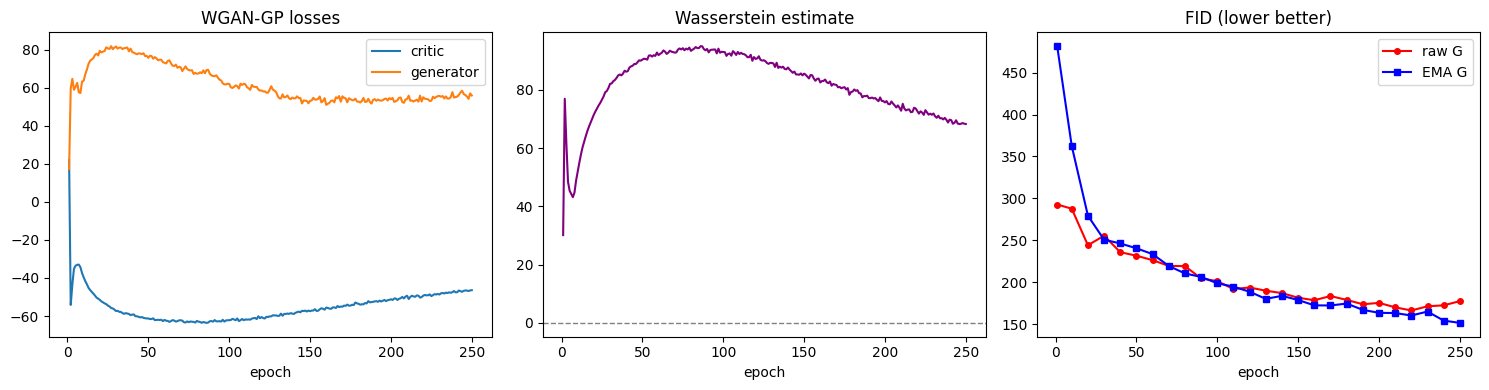

In [13]:
FORCE_RETRAIN = False
ckpt_path = os.path.join(CFG.OUT_DIR, CFG.GEN_CKPT)

if FORCE_RETRAIN or not os.path.exists(ckpt_path):
    gan_hist, gan_best_fid = train_gan()
    # plot training curves
    xs = range(1, len(gan_hist["c"]) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(xs, gan_hist["c"], label="critic"); ax[0].plot(xs, gan_hist["g"], label="generator")
    ax[0].set_title("WGAN-GP losses"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(xs, gan_hist["w"], "purple"); ax[1].axhline(0, color="grey", ls="--", lw=1)
    ax[1].set_title("Wasserstein estimate"); ax[1].set_xlabel("epoch")
    ax[2].plot(gan_hist["fe"], gan_hist["fid_raw"], "r-o", ms=4, label="raw G")
    ax[2].plot(gan_hist["fe"], gan_hist["fid"], "b-s", ms=4, label="EMA G")
    ax[2].set_title("FID (lower better)"); ax[2].set_xlabel("epoch"); ax[2].legend()
    plt.tight_layout(); plt.show()
else:
    print(f"Loaded pretrained generator: {ckpt_path}")
    print("(set FORCE_RETRAIN=True to retrain from scratch)")

**Sample from the trained generator.** A grid of fresh synthetic minority-class MRIs from the best-FID checkpoint.

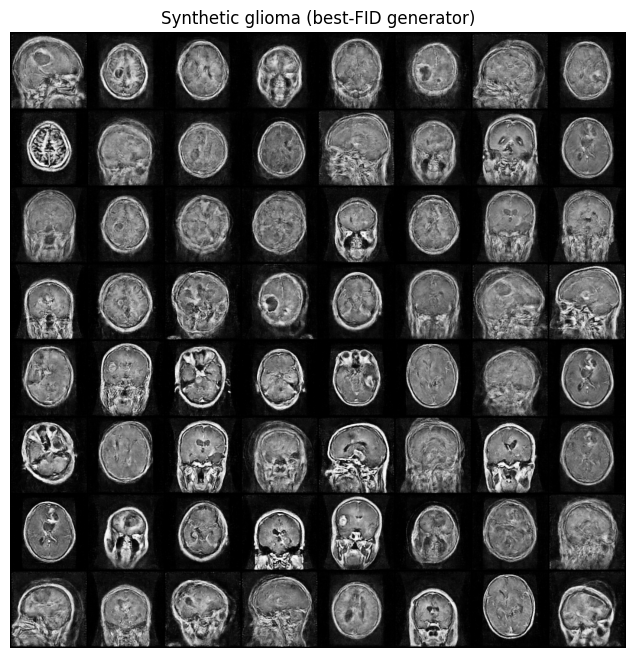

In [14]:
G_final = Generator().to(device).eval()
G_final.load_state_dict(torch.load(ckpt_path, map_location=device))
with torch.no_grad():
    samples = to01(G_final(torch.randn(64, CFG.Z_DIM, device=device))).cpu()
grid = vutils.make_grid(samples, nrow=8, padding=2).permute(1, 2, 0).numpy()
plt.figure(figsize=(8, 8)); plt.imshow(grid); plt.axis("off")
plt.title(f"Synthetic {CFG.MINORITY_CLASS} (best-FID generator)"); plt.show()

## 5 · Synthetic augmentation

**Why this should beat classic augmentation (theory).** Flips/rotations only
recycle the same 178 glioma images; a GAN samples *new* plausible images from the
learned class distribution (new shapes/positions/views), adding genuine variation
to sharpen the glioma decision boundary.

**No double-CLAHE.** The generator was trained on CLAHE-encoded reals, so its
outputs are *already* in that domain. We save synthetic images as the final
encoded image and load them **without** re-applying CLAHE; real images still get
CLAHE. `MixedMRIDataset` keeps the two paths separate.

In [15]:
SYNTH_DIR = os.path.join(CFG.OUT_DIR, "synthetic_glioma")

@torch.no_grad()
def generate_synthetic(n, seed=1234, batch=100, regenerate=False):
    os.makedirs(SYNTH_DIR, exist_ok=True)
    existing = sorted(f for f in os.listdir(SYNTH_DIR) if f.endswith(".png"))
    if not regenerate and len(existing) == n:
        print(f"reusing {n} existing synthetic images")
        return [os.path.join(SYNTH_DIR, f) for f in existing]
    set_seed(seed)
    for f in existing:
        os.remove(os.path.join(SYNTH_DIR, f))
    G = Generator().to(device).eval()
    G.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, CFG.GEN_CKPT), map_location=device))
    paths, made = [], 0
    while made < n:
        b = min(batch, n - made)
        imgs = G(torch.randn(b, CFG.Z_DIM, device=device)).clamp(-1, 1).cpu()
        imgs = ((imgs + 1)/2 * 255).to(torch.uint8)
        for i in range(b):
            p = os.path.join(SYNTH_DIR, f"synth_gl_{made+i:05d}.png")
            Image.fromarray(imgs[i, 0].numpy(), mode="L").save(p); paths.append(p)
        made += b
    print(f"saved {len(paths)} synthetic images -> {SYNTH_DIR}")
    return paths

def load_synth_tensor(path):
    img = Image.open(path).convert("L")
    if img.size != (CFG.IMG_SIZE, CFG.IMG_SIZE):
        img = img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).unsqueeze(0) * 2.0 - 1.0   # NO CLAHE

class MixedMRIDataset(Dataset):
    def __init__(self, real_items, synth_items, augment=False):
        self.cache, self.labels = [], []
        for p, l in real_items:
            self.cache.append(preprocess_image(p)); self.labels.append(l)
        for p, l in synth_items:
            self.cache.append(load_synth_tensor(p)); self.labels.append(l)
        self.augment = augment
    def __len__(self):
        return len(self.cache)
    def __getitem__(self, i):
        x = self.cache[i]
        if self.augment and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
        return x, self.labels[i]

def build_augmented_train(verbose=True):
    tr, va, te = build_splits(verbose=False)
    idx = CFG.CLASSES.index(CFG.MINORITY_CLASS)
    n_real = sum(1 for _, l in tr if l == idx)
    n_synth = max(0, CFG.AUG_TARGET - n_real)
    synth = [(p, idx) for p in generate_synthetic(n_synth)]
    if verbose:
        print(f"real {CFG.MINORITY_CLASS}={n_real}  synthetic={n_synth}  "
              f"total={n_real+n_synth} (target {CFG.AUG_TARGET})")
    return tr, synth, va, te

/tmp/ipykernel_378/280893868.py:22: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(imgs[i, 0].numpy(), mode="L").save(p); paths.append(p)


saved 1012 synthetic images -> outputs/synthetic_glioma
real glioma=178  synthetic=1012  total=1190 (target 1190)


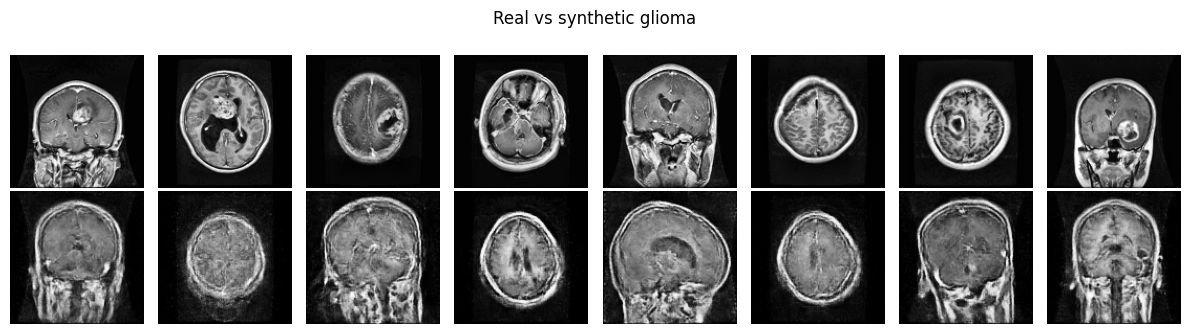

In [16]:
real_train, synth_items, val_items, test_items = build_augmented_train()

# real vs synthetic comparison
idx = CFG.CLASSES.index(CFG.MINORITY_CLASS)
rp = [p for p, l in real_train if l == idx][:8]; sp = [p for p, _ in synth_items][:8]
fig, ax = plt.subplots(2, 8, figsize=(12, 3.4))
for c in range(8):
    ax[0, c].imshow((preprocess_image(rp[c])[0].numpy()+1)/2, cmap="gray"); ax[0, c].axis("off")
    ax[1, c].imshow((load_synth_tensor(sp[c])[0].numpy()+1)/2, cmap="gray"); ax[1, c].axis("off")
ax[0, 0].set_ylabel("real", rotation=0, labelpad=22); ax[1, 0].set_ylabel("synth", rotation=0, labelpad=22)
fig.suptitle("Real vs synthetic glioma"); fig.tight_layout(); plt.show()

## 6 · Re-train on augmented data & compare

Same `SmallCNN`, same protocol, same seed, same val/test — the **only** difference
is the training data (real-only vs real+synthetic). So any change in test metrics
is attributable to the synthetic augmentation.


=== train [augmented] : 4760 imgs, 15 epochs ===
epoch  1/15  loss=0.6800  val_macroF1=0.1617  * best
epoch  2/15  loss=0.4418  val_macroF1=0.2747  * best
epoch  3/15  loss=0.3549  val_macroF1=0.7877  * best
epoch  4/15  loss=0.2933  val_macroF1=0.3134
epoch  5/15  loss=0.2774  val_macroF1=0.8365  * best
epoch  6/15  loss=0.2372  val_macroF1=0.7982
epoch  7/15  loss=0.2346  val_macroF1=0.7597
epoch  8/15  loss=0.1933  val_macroF1=0.8097
epoch  9/15  loss=0.1875  val_macroF1=0.8463  * best
epoch 10/15  loss=0.1700  val_macroF1=0.7116
epoch 11/15  loss=0.1732  val_macroF1=0.7835
epoch 12/15  loss=0.1475  val_macroF1=0.7921
epoch 13/15  loss=0.1411  val_macroF1=0.6308
epoch 14/15  loss=0.1211  val_macroF1=0.8432
epoch 15/15  loss=0.1171  val_macroF1=0.7279
best epoch=9 (val macroF1=0.8463)

--- TEST [augmented] (best-val checkpoint) ---
              precision    recall  f1-score   support

      glioma     0.9277    0.5450    0.6866       400
  meningioma     0.5783    0.9325    0.7139 

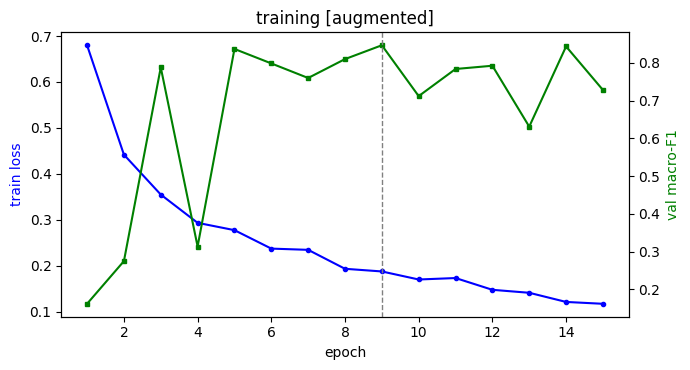

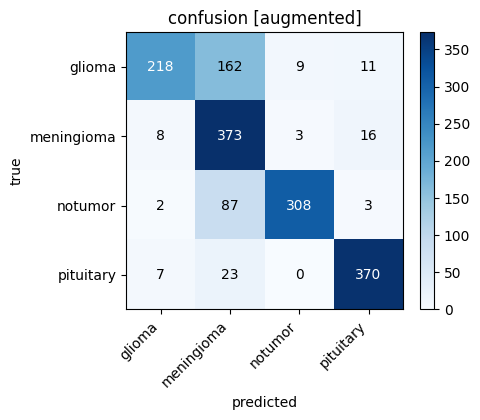

In [17]:
aug_train_ds = MixedMRIDataset(real_train, synth_items, augment=True)
res_aug = run_experiment(real_train, val_items, test_items, tag="augmented", train_ds=aug_train_ds)
show_confusion(res_aug["confusion"], "augmented")

metric                      baseline  augmented    delta
glioma precision              1.0000     0.9277  -0.0723
glioma recall                 0.4075     0.5450  +0.1375
glioma f1                     0.5790     0.6866  +0.1076
--------------------------------------------------------
glioma f1                     0.5790     0.6866  +0.1076
meningioma f1                 0.7288     0.7139  -0.0149
notumor f1                    0.7988     0.8556  +0.0568
pituitary f1                  0.9433     0.9250  -0.0183
--------------------------------------------------------
macro-F1 (test)               0.7625     0.7953  +0.0328
accuracy                      0.7788     0.7931  +0.0144


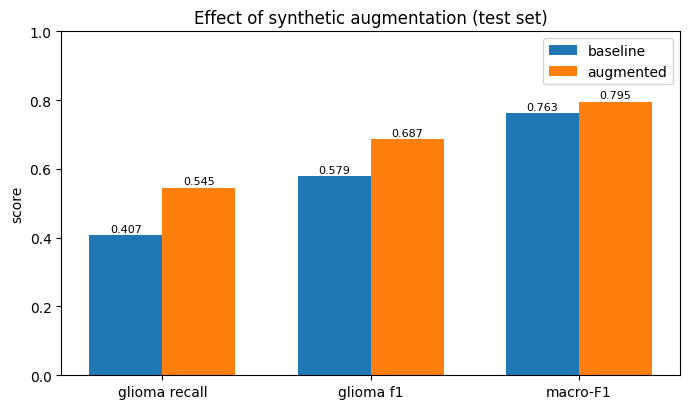

In [21]:
gl = CFG.MINORITY_CLASS
rb, ra = res_baseline["report"], res_aug["report"]
def line(name, b, a):
    print(f"{name:<26}{b:>10.4f}{a:>11.4f}{a-b:>+9.4f}")
print(f"{'metric':<26}{'baseline':>10}{'augmented':>11}{'delta':>9}")
line(f"{gl} precision", rb[gl]['precision'], ra[gl]['precision'])
line(f"{gl} recall",    rb[gl]['recall'],    ra[gl]['recall'])
line(f"{gl} f1",        rb[gl]['f1-score'],  ra[gl]['f1-score'])
print("-"*56)
for c in CFG.CLASSES:
    line(f"{c} f1", rb[c]['f1-score'], ra[c]['f1-score'])
print("-"*56)
line("macro-F1 (test)", res_baseline['test_macro_f1'], res_aug['test_macro_f1'])
line("accuracy", rb['accuracy'], ra['accuracy'])

labels = ["glioma recall", "glioma f1", "macro-F1"]
bv = [rb[gl]['recall'], rb[gl]['f1-score'], rb['macro avg']['f1-score']]
av = [ra[gl]['recall'], ra[gl]['f1-score'], ra['macro avg']['f1-score']]
x = np.arange(3); w = 0.35
plt.figure(figsize=(7, 4.2))
b1 = plt.bar(x-w/2, bv, w, label="baseline"); b2 = plt.bar(x+w/2, av, w, label="augmented")
plt.xticks(x, labels); plt.ylim(0, 1); plt.ylabel("score")
plt.title("Effect of synthetic augmentation (test set)"); plt.legend()
for bars in (b1, b2):
    for r in bars:
        plt.text(r.get_x()+r.get_width()/2, r.get_height()+0.01, f"{r.get_height():.3f}",
                 ha="center", fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Discussion

**Findings.** The induced imbalance starved the classifier (glioma recall ≈ 0.45).
A WGAN-GP (128 px, CLAHE, TTUR + EMA) learned the glioma distribution to FID ≈ 167
with diverse, plausible samples and no mode collapse. Augmenting to balance lifted
the **target class clearly** (recall +≈0.12, F1 +≈0.08) but **slightly lowered
global macro-F1** — the classic synthetic-augmentation distribution-shift tradeoff.
For the problem we set out to fix (a starved class) augmentation helps; fully
rebalancing with imperfect synthetics has a global cost, so the *amount* of
augmentation is itself a hyperparameter.

**Limitations.** Tiny generator set (178 images → biased/noisy FID, softer
synthetics); single seed, no confidence intervals; *induced* (not natural)
imbalance; 2D single-sequence 128 px vs real 3D multi-sequence MRI; no clinical
validation of synthetics; FID/accuracy are proxies, not measures of medical
correctness.

**Ethics.** *Not for clinical use* — synthetic images can contain anatomically
impossible features and must never inform diagnosis. "Synthetic" is **not**
automatically "private": GANs can memorise and regurgitate training examples, so a
memorisation audit and appropriate data consent/licensing are required before any
real use. A small single-source dataset also **bakes in and amplifies bias**.
Synthetic-augmented results must always be labelled as such.

**Future work.** Sweep the augmentation amount to find the glioma/synthetic ratio
that helps the minority class *and* macro-F1; multi-seed runs with confidence
intervals; a **conditional GAN** to generate all four classes; higher-res / 3D /
multi-sequence generation on Colab CUDA (`IMG_SIZE=256`); stronger generators
(diffusion, StyleGAN); nearest-neighbour **memorisation audits**; and comparison
against cheaper imbalance fixes (class-weighted/focal loss, oversampling).